# 10_01 Final results: what we achieved, and where the remaining error lives

**The task.** For every fresh-meat article in every store, predict how many kilograms
will sell on each day of the coming week. The forecast is scored on 20 consecutive
evaluation weeks (March–July 2026) across ~21,700 article × store combinations
("series"). Every result below is honest out-of-sample: the model sees only data from
*before* the forecast origin — no hindsight.

**The metric.** WAPE (weighted absolute percentage error) answers: *out of every 100 kg
that actually sold, how many kg was the forecast off by — in either direction?*
Lower is better. Alongside it we always report **bias**: whether the forecast
systematically orders too much (+) or too little (−). A forecast that reduces WAPE by
deliberately under-ordering is not a win, so bias must stay near zero.

**The final model** is a LightGBM "two-stage" model: it first estimates *the chance
that anything sells* on a given day, then *how much, if so*, using promotions and
their discount depth, weekday patterns, temperature and recent demand. Its headline
result: **56.9% WAPE at article × store × day, with −0.3% bias.**

**The questions this notebook answers:**

1. **Where does the remaining error live — in the model or in the data?** Stated in
   uncertainty language: how much is *aleatoric* (irreducible randomness) and how much
   is *epistemic* (removable with better models or more data)?
2. **Do forecasts get worse over the week ahead** (day 1 vs day 6 of the horizon)?
3. **Which products are already forecast well (< 20% / < 30% WAPE), and *why* exactly
   those?**
4. **In which sourcing group does the biggest problem sit?**

Deep-dives behind individual claims: oracle analysis in notebook `09_01`, feature
batches in `05_06`–`08_04`, seed study in `07_02`.


In [1]:
from pathlib import Path
import sys

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design
from src.models.lightgbm import TWO_STAGE_MODEL_NAME
from src.models.results import result_path

pd.set_option('display.max_columns', 40)

# -- shared chart style (light surface, recessive chrome) ----------------------
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
BLUE, ORANGE, AQUA, GRAY = '#2a78d6', '#eb6834', '#1baf7a', '#c3c2b7'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': BASELINE, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
})


def style_ax(ax, ygrid=True, xgrid=False):
    for side in ('top', 'right', 'left'):
        ax.spines[side].set_visible(False)
    ax.spines['bottom'].set_color(BASELINE)
    if ygrid:
        ax.grid(axis='y', color=GRID, linewidth=0.8)
    if xgrid:
        ax.grid(axis='x', color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


design = load_benchmark_design()
con = duckdb.connect()
con.execute('PRAGMA threads=4')

# final-model rows: one forecast per article x store x day, active rows only
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE rows AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           sourcing_group, category_id::INTEGER AS category_id,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           DATEDIFF('day', CAST(origin AS DATE), CAST(period AS DATE)) + 1 AS horizon_day,
           actual::DOUBLE AS actual, forecast::DOUBLE AS forecast,
           occurrence_probability::DOUBLE AS p_occ,
           positive_quantity_forecast::DOUBLE AS q_fc,
           EXTRACT(ISODOW FROM CAST(period AS DATE)) AS weekday
    FROM read_csv_auto(?)
    WHERE is_active
    ''',
    [str(result_path(TWO_STAGE_MODEL_NAME, design))],
)

# readable article names and store numbers from the transaction data
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE article_names AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, ANY_VALUE(ARTIKEL_BEZ) AS article_name
    FROM read_parquet(?) GROUP BY 1
    ''',
    [str(design.data_dir / '*.parquet')],
)
con.execute(
    '''
    CREATE OR REPLACE TEMP TABLE store_numbers AS
    SELECT MARKT_ID::BIGINT AS MARKT_ID, ANY_VALUE(MARKT_NR) AS store_nr
    FROM read_parquet(?) GROUP BY 1
    ''',
    [str(design.data_dir / '*.parquet')],
)

overview = con.execute('''
    SELECT COUNT(*) AS forecast_rows,
           COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
           COUNT(DISTINCT origin) AS evaluation_weeks,
           SUM(actual) AS total_kg_sold,
           AVG((actual > 0)::INTEGER) AS share_of_days_with_a_sale,
           SUM(ABS(forecast - actual)) / SUM(actual) AS wape_day_level,
           SUM(forecast - actual) / SUM(actual) AS bias
    FROM rows
''').fetchdf()
assert int(overview.evaluation_weeks[0]) == design.max_origins
display(overview.style.format({
    'forecast_rows': '{:,.0f}', 'series': '{:,.0f}',
    'total_kg_sold': '{:,.0f}', 'share_of_days_with_a_sale': '{:.1%}',
    'wape_day_level': '{:.1%}', 'bias': '{:+.1%}',
}).hide(axis='index'))


forecast_rows,series,evaluation_weeks,total_kg_sold,share_of_days_with_a_sale,wape_day_level,bias
"2,498,967","21,922",20,"2,661,595",38.0%,56.9%,-0.3%


## 1 · What the task actually looks like

Before any numbers: the chart below shows the same forecasting task for two real
articles. On the left, minced meat in one store — it sells every single day, and the
question is only *how much*. On the right, a typical article-store series: it sells on
roughly one day in three, and when it sells, the amount jumps around. **Two thirds of
all series look more like the right panel than the left** (the average series has a
sale on 38% of days).

This intermittency is the defining property of the data — and, as the rest of the
notebook shows, the main source of the remaining error.


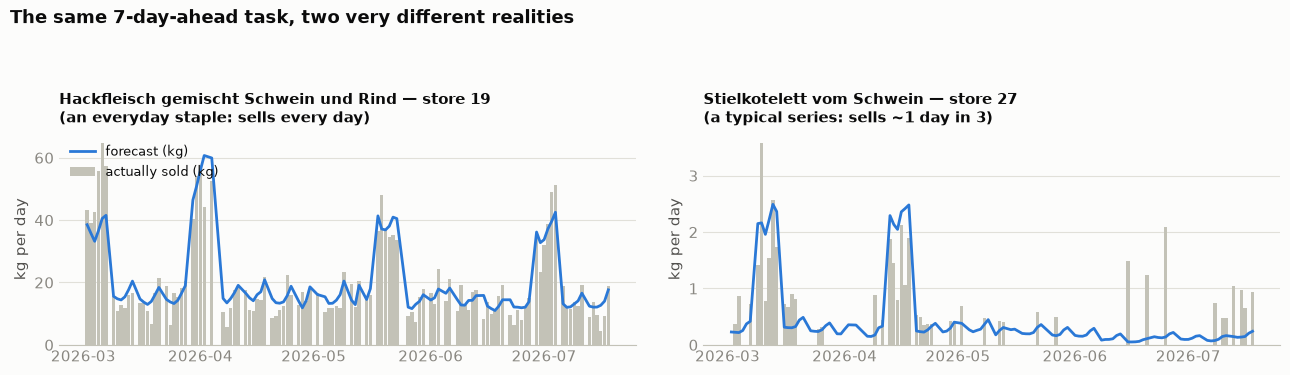

In [2]:
example_best = con.execute('''
    SELECT r.period, r.actual, r.forecast, a.article_name, s.store_nr
    FROM rows r JOIN article_names a USING (ARTIKEL_ID) JOIN store_numbers s USING (MARKT_ID)
    WHERE r.ARTIKEL_ID = 316623 AND r.MARKT_ID = 1150019 ORDER BY r.period
''').fetchdf()

# a deliberately typical series: occurrence rate near the population average,
# volume near the median of such series
typical_key = con.execute('''
    WITH per_series AS (
        SELECT ARTIKEL_ID, MARKT_ID, AVG((actual > 0)::INTEGER) AS occ, SUM(actual) AS kg
        FROM rows GROUP BY 1, 2
    ), near AS (SELECT * FROM per_series WHERE occ BETWEEN 0.30 AND 0.40 AND kg > 0)
    SELECT ARTIKEL_ID, MARKT_ID FROM near
    ORDER BY ABS(kg - (SELECT MEDIAN(kg) FROM near)), ARTIKEL_ID, MARKT_ID LIMIT 1
''').fetchone()
example_typical = con.execute('''
    SELECT r.period, r.actual, r.forecast, a.article_name, s.store_nr
    FROM rows r JOIN article_names a USING (ARTIKEL_ID) JOIN store_numbers s USING (MARKT_ID)
    WHERE r.ARTIKEL_ID = ? AND r.MARKT_ID = ? ORDER BY r.period
''', list(typical_key)).fetchdf()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=False)
for ax, frame, subtitle in (
    (axes[0], example_best, 'an everyday staple: sells every day'),
    (axes[1], example_typical, 'a typical series: sells ~1 day in 3'),
):
    ax.bar(frame.period, frame.actual, width=0.9, color=GRAY, label='actually sold (kg)')
    ax.plot(frame.period, frame.forecast, color=BLUE, linewidth=2, label='forecast (kg)')
    style_ax(ax)
    name = frame.article_name.iloc[0]
    ax.set_title(f'{name[:38]} — store {frame.store_nr.iloc[0]}\n({subtitle})',
                 fontsize=11, pad=8)
    ax.set_ylabel('kg per day')
axes[0].legend(frameon=False, loc='upper left', fontsize=9)
fig.suptitle('The same 7-day-ahead task, two very different realities', x=0.01,
             ha='left', fontweight='bold', fontsize=13)
fig.autofmt_xdate(rotation=0, ha='center')
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()


## 2 · Model or data? What perfect information would buy

The headline 56.9% sounds large. The right question is: **how much of it could *any*
forecast remove?** To answer it without speculation, notebook `09_01` builds
*oracles* — fake "forecasters" that are handed information no real forecast can have,
taken from the actual future:

- one oracle is told **exactly which days each product will sell** (it only has to
  guess the amount, using the model's own amount estimate);
- one additionally knows each product's **true average sale size per weekday over the
  whole evaluation period**;
- one is told each series' **exact weekly total** and only has to spread it over the
  days using the true weekday pattern.

If even these cheating forecasts miss by 40%+ at day–store level, that part of the
error is **randomness in the data** — which customer happens to walk into which store
on which day — and no model investment can remove it.


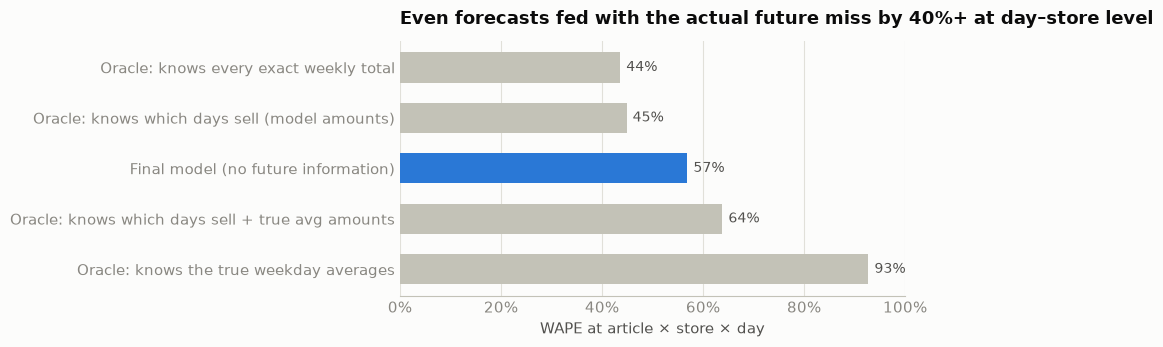

who,kind,wape
Oracle: knows the true weekday averages,oracle,92.8%
Oracle: knows which days sell + true avg amounts,oracle,63.8%
Final model (no future information),model,56.9%
Oracle: knows which days sell (model amounts),oracle,44.9%
Oracle: knows every exact weekly total,oracle,43.6%


In [3]:
def row_wape(forecast_sql):
    return con.execute(f'SELECT SUM(ABS(fo - actual)) / SUM(actual) '
                       f'FROM ({forecast_sql})').fetchone()[0]

ladder = pd.DataFrame([
    {'who': 'Final model (no future information)', 'kind': 'model',
     'wape': row_wape('SELECT actual, forecast AS fo FROM rows')},
    {'who': 'Oracle: knows the true weekday averages', 'kind': 'oracle',
     'wape': row_wape('''SELECT actual, AVG(actual) OVER
                         (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday) AS fo FROM rows''')},
    {'who': 'Oracle: knows which days sell + true avg amounts', 'kind': 'oracle',
     'wape': row_wape('''
        WITH s AS (SELECT ARTIKEL_ID, MARKT_ID, weekday,
                          AVG(actual) FILTER (WHERE actual > 0) AS mu
                   FROM rows GROUP BY 1, 2, 3)
        SELECT rows.actual,
               CASE WHEN rows.actual > 0 THEN COALESCE(s.mu, 0) ELSE 0 END AS fo
        FROM rows JOIN s USING (ARTIKEL_ID, MARKT_ID, weekday)''')},
    {'who': 'Oracle: knows which days sell (model amounts)', 'kind': 'oracle',
     'wape': row_wape('''SELECT actual,
                         CASE WHEN actual > 0 THEN q_fc ELSE 0 END AS fo FROM rows''')},
    {'who': 'Oracle: knows every exact weekly total', 'kind': 'oracle',
     'wape': row_wape('''
        WITH wd AS (SELECT ARTIKEL_ID, MARKT_ID, weekday, AVG(actual) AS mu
                    FROM rows GROUP BY 1, 2, 3),
        j AS (SELECT rows.*, wd.mu FROM rows JOIN wd USING (ARTIKEL_ID, MARKT_ID, weekday)),
        wk AS (SELECT *,
                      SUM(actual) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin) AS wt,
                      SUM(mu) OVER (PARTITION BY ARTIKEL_ID, MARKT_ID, origin) AS ms
               FROM j)
        SELECT actual, CASE WHEN ms > 0 THEN wt * mu / ms ELSE 0 END AS fo FROM wk''')},
]).sort_values('wape', ascending=False)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
colors = [BLUE if k == 'model' else GRAY for k in ladder.kind]
bars = ax.barh(ladder.who, ladder.wape * 100, color=colors, height=0.6)
for bar, wape in zip(bars, ladder.wape):
    ax.annotate(f'{wape:.0%}', (bar.get_width() + 1.2,
                bar.get_y() + bar.get_height() / 2), va='center',
                fontsize=10, color=INK2)
style_ax(ax, ygrid=False, xgrid=True)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)
ax.set_xlabel('WAPE at article × store × day')
ax.set_title('Even forecasts fed with the actual future miss by 40%+ at day–store level',
             pad=12)
plt.tight_layout()
plt.show()
display(ladder.style.format({'wape': '{:.1%}'}).hide(axis='index'))


**Reading the ladder — the central result of this notebook.**

- Two of the oracles are actually **worse** than the model: knowing every product's
  *true average* per weekday (93%) or even the true average *given that it sells*
  (64%) loses to the model's 57%. Averages are not the problem — daily demand
  fluctuates so strongly around any average that a static "right" number misses
  badly. The model already beats perfect averages by exploiting recent demand,
  promotions and weather.
- The two genuinely valuable pieces of future information — **which days will sell**
  (45%) and **the exact weekly totals** (44%) — still leave the error at ~44–45%.

**The verdict on "model vs data":** of the 57 error-kilograms per 100 kg sold, at
most ~12 could be removed by a *perfect* predictor of sell-days (57% → 45%), and a
realistic predictor captures only a fraction of that. The rest — roughly four fifths
of the remaining error — is **demand randomness at the single-store, single-day
level**. Section 7 puts this in formal uncertainty language and adds the evidence on
the model side.


## 3 · Which products are already forecast well?

For each of the ~21,700 article × store series we pool its full 20 evaluation weeks
and compute its own WAPE, at two levels: **day-level** (right amount on the right
day) and **week-level** (right weekly total per store). "Selling occurrence" is the
share of evaluation days on which the product actually sold at least once in that
store.


In [4]:
per_series = con.execute('''
    WITH day_grain AS (
        SELECT ARTIKEL_ID, MARKT_ID,
               ANY_VALUE(sourcing_group) AS sourcing_group,
               ANY_VALUE(category_id) AS category_id,
               SUM(actual) AS actual_kg,
               AVG(actual) AS mean_daily_kg,
               AVG((actual > 0)::INTEGER) AS selling_occurrence,
               SUM(ABS(forecast - actual)) / NULLIF(SUM(actual), 0) AS wape_day,
               SUM(forecast - actual) / NULLIF(SUM(actual), 0) AS bias,
               STDDEV_POP(actual) / NULLIF(AVG(actual), 0) AS cv
        FROM rows GROUP BY 1, 2
    ),
    week_grain AS (
        SELECT ARTIKEL_ID, MARKT_ID,
               SUM(ABS(f - a)) / NULLIF(SUM(a), 0) AS wape_week
        FROM (SELECT ARTIKEL_ID, MARKT_ID, origin,
                     SUM(actual) AS a, SUM(forecast) AS f
              FROM rows GROUP BY 1, 2, 3)
        GROUP BY 1, 2
    ),
    weekday_fit AS (   -- share of a series' day-to-day variance explained by weekday
        SELECT ARTIKEL_ID, MARKT_ID,
               1 - AVG(POW(actual - wm, 2)) / NULLIF(VAR_POP(actual), 0) AS weekday_r2
        FROM (SELECT r.*, AVG(actual) OVER
                  (PARTITION BY ARTIKEL_ID, MARKT_ID, weekday) AS wm FROM rows r)
        GROUP BY 1, 2
    )
    SELECT d.*, w.wape_week, f.weekday_r2, a.article_name, s.store_nr
    FROM day_grain d
    JOIN week_grain w USING (ARTIKEL_ID, MARKT_ID)
    JOIN weekday_fit f USING (ARTIKEL_ID, MARKT_ID)
    JOIN article_names a USING (ARTIKEL_ID)
    JOIN store_numbers s USING (MARKT_ID)
    WHERE d.actual_kg > 0
''').fetchdf()
per_series['volume_share'] = per_series.actual_kg / per_series.actual_kg.sum()

threshold_summary = pd.DataFrame([
    {'threshold': thr, 'level': level,
     'series_below': int((per_series[col] < thr).sum()),
     'volume_share_below': per_series.loc[per_series[col] < thr, 'volume_share'].sum()}
    for col, level in (('wape_day', 'day-level'), ('wape_week', 'week-level'))
    for thr in (0.20, 0.30)
])
display(threshold_summary.style.format({'threshold': '{:.0%}', 'series_below': '{:,.0f}',
                                        'volume_share_below': '{:.1%}'}).hide(axis='index'))

SHOW = ['article_name', 'store_nr', 'sourcing_group', 'category_id',
        'selling_occurrence', 'actual_kg', 'wape_day', 'wape_week', 'bias']
FMT = {'selling_occurrence': '{:.0%}', 'actual_kg': '{:,.0f}',
       'wape_day': '{:.1%}', 'wape_week': '{:.1%}', 'bias': '{:+.1%}'}

print('Series below 20% day-level WAPE:')
display(per_series[per_series.wape_day < 0.20][SHOW]
        .sort_values('wape_day').style.format(FMT).hide(axis='index'))

print('Series below 30% day-level WAPE — top 15 by volume (of '
      f'{(per_series.wape_day < 0.30).sum()} in total):')
display(per_series[per_series.wape_day < 0.30][SHOW]
        .sort_values('actual_kg', ascending=False).head(15)
        .style.format(FMT).hide(axis='index'))

good = per_series[per_series.wape_day < 0.30]
print('What the <30% (day-level) set consists of, per article:')
display(good.groupby('article_name', observed=True)
        .agg(stores=('store_nr', 'count'), total_kg=('actual_kg', 'sum'),
             mean_occurrence=('selling_occurrence', 'mean'),
             mean_wape_day=('wape_day', 'mean'))
        .sort_values('stores', ascending=False)
        .style.format({'total_kg': '{:,.0f}', 'mean_occurrence': '{:.0%}',
                       'mean_wape_day': '{:.1%}'}))


threshold,level,series_below,volume_share_below
20%,day-level,1,0.1%
30%,day-level,229,13.1%
20%,week-level,649,18.3%
30%,week-level,"2,519",42.0%


Series below 20% day-level WAPE:


article_name,store_nr,sourcing_group,category_id,selling_occurrence,actual_kg,wape_day,wape_week,bias
Hackfleisch gemischt Schwein und Rind,19,Pseudo,890,100%,"2,280",18.7%,11.2%,+1.0%


Series below 30% day-level WAPE — top 15 by volume (of 229 in total):


article_name,store_nr,sourcing_group,category_id,selling_occurrence,actual_kg,wape_day,wape_week,bias
Hackfleisch gemischt Schwein und Rind,9,Pseudo,890,100%,"5,266",22.5%,16.5%,-4.0%
Hackfleisch gemischt Schwein und Rind,23,Pseudo,890,100%,"4,580",23.7%,17.2%,-7.1%
Hackfleisch gemischt Schwein und Rind,19,Pseudo,890,100%,"4,128",29.2%,23.5%,-12.7%
Hackfleisch gemischt Schwein und Rind,7,Pseudo,890,100%,"3,989",25.2%,20.1%,-0.5%
Hackfleisch gemischt Schwein und Rind,6,Pseudo,890,100%,"3,822",24.3%,16.7%,+4.9%
Hackfleisch gemischt Schwein und Rind,12,Pseudo,890,100%,"3,528",20.6%,13.2%,-4.7%
Hackfleisch gemischt Schwein und Rind,25,Pseudo,890,100%,"3,354",22.4%,14.9%,-4.0%
Hackfleisch gemischt Schwein und Rind,45,Pseudo,890,100%,"3,321",22.3%,14.5%,-11.4%
Hackfleisch gemischt Schwein und Rind,4,Pseudo,890,100%,"3,313",23.3%,16.1%,-2.8%
Hackfleisch gemischt Schwein und Rind,47,Pseudo,890,100%,"3,184",24.5%,14.6%,-5.4%


What the <30% (day-level) set consists of, per article:


,stores,total_kg,mean_occurrence,mean_wape_day
article_name,,,,
Hackfleisch gemischt Schwein und Rind,116,"224,364",100%,25.9%
"Gyrospfanne, Schinkenfleisch in Streifen, gewürzt",40,"58,273",97%,25.5%
Hackfleisch vom Rind,25,"26,143",100%,26.8%
Schinkenmett gewürzt vom Schwein,21,"19,112",76%,26.3%
Thüringer Mett vom Schwein,11,"12,960",87%,27.2%
Thüringer Mett mit Zwiebeln vom Schwein,6,"3,773",99%,27.4%
Grobe Bratwurst vom Schwein,3,"2,684",100%,26.1%
Jägerpfanne vom Schwein,2,465,23%,27.3%
"Nackensteaks vom Schwein, in Zwiebeln eingelegt",2,116,11%,24.2%


**Reading.** At the day-level standard, exactly **one** series in ~21,700 beats
20%: mixed minced meat (*Hackfleisch gemischt Schwein und Rind*) in store 19 — 18.7%
WAPE, selling on 100% of days. **229 series beat 30%**, and they carry a
disproportionate 13.1% of all kilograms sold. The per-article breakdown shows what
they are: twelve articles, essentially the fresh-counter staples — mixed minced meat
(116 stores), gyros strips (40), beef mince (25), seasoned Mett (21+11+6), fresh
Bratwurst (3) — selling on ~95% of days on average.

At the **week-level** standard the picture is much friendlier: 649 series beat 20%
and **2,519 series (42% of all volume) beat 30%**.

So the well-forecast set is a handful of high-frequency staples. The next section
asks *why* — is it a strong weekly rhythm ("good seasonality"), or something else?


## 4 · Why exactly these products? Testing the "good seasonality" hypothesis

Three candidate explanations for why the staples forecast so well:

1. **Good seasonality** — a strong, stable weekday rhythm the model can lock onto.
   Measured per series as *weekday R²*: the share of its day-to-day variance
   explained by its own weekday averages.
2. **Calm demand** — day-to-day amounts vary little (low coefficient of variation).
3. **Scale** — many customers per day, so individual randomness averages out
   (counting statistics: relative noise shrinks like 1/√volume).

To compare like with like, we restrict to the 1,409 series that sell on ≥ 90% of days
(the population the < 30% set comes from) and compare the sub-30% series with the
rest:


,n_series,mean_daily_kg,weekday_r2,cv,wape_day
below_30,,,,,
other ≥90%-occurrence series,"1,199",4.3,0.18,0.97,44.2%
the <30% WAPE series,210,12.8,0.02,0.85,26.6%


,rank corr with WAPE
mean_daily_kg,-0.63
weekday_r2,+0.27
cv,+0.22


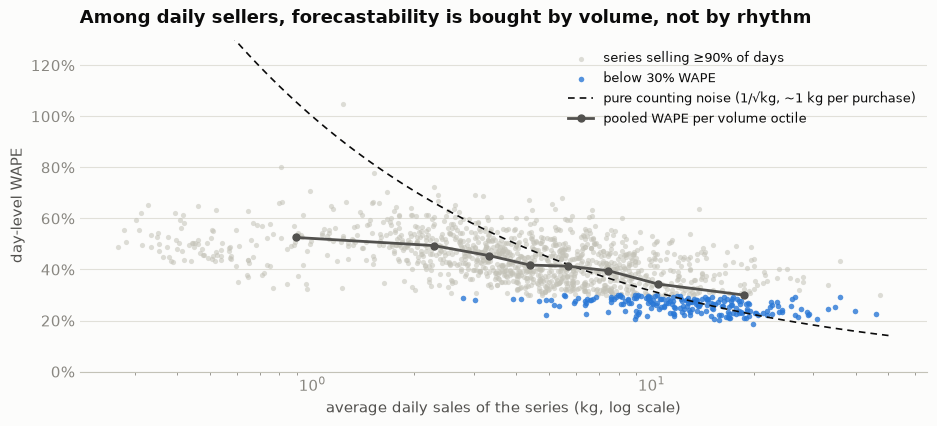

In [5]:
highocc = per_series[per_series.selling_occurrence >= 0.9].copy()
highocc['below_30'] = highocc.wape_day < 0.30

comparison = highocc.groupby('below_30')[
    ['mean_daily_kg', 'weekday_r2', 'cv', 'wape_day']].median()
comparison.index = comparison.index.map(
    {False: 'other ≥90%-occurrence series', True: 'the <30% WAPE series'})
comparison['n_series'] = highocc.below_30.value_counts().rename(
    {False: 'other ≥90%-occurrence series', True: 'the <30% WAPE series'})
display(comparison[['n_series', 'mean_daily_kg', 'weekday_r2', 'cv', 'wape_day']]
        .style.format({'n_series': '{:,.0f}', 'mean_daily_kg': '{:.1f}',
                       'weekday_r2': '{:.2f}', 'cv': '{:.2f}', 'wape_day': '{:.1%}'}))

rank_corr = highocc[['wape_day', 'mean_daily_kg', 'weekday_r2', 'cv']].corr(
    method='spearman')['wape_day'].drop('wape_day').rename('rank corr with WAPE')
display(rank_corr.to_frame().style.format('{:+.2f}'))

# volume octiles: pooled WAPE falls monotonically with daily volume
highocc['volume_octile'] = pd.qcut(highocc.mean_daily_kg, 8)
octiles = highocc.groupby('volume_octile', observed=True).apply(
    lambda g: pd.Series({
        'mean_daily_kg': g.mean_daily_kg.mean(),
        'pooled_wape': (g.wape_day * g.actual_kg).sum() / g.actual_kg.sum(),
    }), include_groups=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.scatter(highocc.loc[~highocc.below_30, 'mean_daily_kg'],
           highocc.loc[~highocc.below_30, 'wape_day'] * 100,
           s=14, color=GRAY, alpha=0.55, linewidths=0,
           label='series selling ≥90% of days')
ax.scatter(highocc.loc[highocc.below_30, 'mean_daily_kg'],
           highocc.loc[highocc.below_30, 'wape_day'] * 100,
           s=16, color=BLUE, alpha=0.8, linewidths=0,
           label='below 30% WAPE')
mu_grid = np.geomspace(0.3, 50, 100)
ax.plot(mu_grid, 100 / np.sqrt(mu_grid), color=INK, linewidth=1.2,
        linestyle=(0, (4, 3)),
        label='pure counting noise (1/√kg, ~1 kg per purchase)')
ax.plot(octiles.mean_daily_kg, octiles.pooled_wape * 100, color=INK2, linewidth=2,
        marker='o', markersize=5, label='pooled WAPE per volume octile')
style_ax(ax)
ax.set_xscale('log')
ax.set_xlabel('average daily sales of the series (kg, log scale)')
ax.set_ylabel('day-level WAPE')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 130)
ax.set_title('Among daily sellers, forecastability is bought by volume, not by rhythm',
             pad=12)
ax.legend(frameon=False, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()


**Reading — the seasonality hypothesis is wrong, scale is the answer.**

- The < 30% series have **weaker weekday seasonality** than their peers (median
  weekday R² 0.02 vs 0.18) and only slightly calmer demand (CV 0.85 vs 0.97). If a
  strong weekly rhythm were the driver, both numbers would point the other way.
- What actually separates them is **volume**: they sell a median of ~13 kg per day
  vs ~4 kg for the rest — and volume has by far the strongest (negative) rank
  correlation with WAPE.
- The mechanism is counting statistics: a day's sales are the sum of many individual
  customer decisions. With ~N kilogram-sized purchases a day, pure chance already
  produces a relative error of about 1/√N. The dashed curve shows that reference
  line; the pooled WAPE of the largest staples runs close to it — mixed minced meat
  at ~14 kg/day is near its **theoretical noise floor of ~25%**, which is why nothing
  gets meaningfully below ~19% and why the "< 20% club" has exactly one member.
- Weekday rhythm, promotions and weather are not useless — they are what lifts the
  model above the naive references — but among daily sellers they are already
  exploited; the *residual* differences in WAPE are set by scale.

**Implication:** the WAPE of a product is largely a property of its sales volume.
Aggregating slow series (across stores, or across days into weekly totals) is the
only reliable way to move more of the assortment into the well-forecastable regime —
it is exactly the same averaging effect, applied deliberately.


## 5 · Do forecasts get worse over the week ahead?

Each Monday origin forecasts the following days t+1 … t+6 (Monday through Saturday;
stores are closed on Sundays). One structural caveat must be stated before reading
any curve: **in this backtest, lead time and weekday are the same thing** — day t+1
is always a Monday, day t+6 always a Saturday, and every calendar day is forecast
exactly once. A raw "WAPE by horizon day" therefore mixes two effects: information
getting stale, and Saturdays simply being easier (they are the highest-volume days —
section 4's scale effect).

To separate the two we use the same-weekday moving average as a **weekday-matched
yardstick**: it knows the weekday but has the same information cut-off and no
short-term signal to lose. The model's error *as a share of the yardstick's error*
is then comparable across days: if the model's informational edge decays with lead
time, that share rises.

Where segmentation is needed we use the frozen **ADI terciles A1/A2/A3** (average
days between sales, classified before the first origin, as in `09_01`/`09_02`):
A1 = frequent sellers, A3 = sporadic sellers.


horizon_day,weekday,wape_model,wape_naive,error_vs_naive,wape_A1,wape_A2,wape_A3
1,Mon,58.9%,113.8%,51.7%,50.4%,80.2%,91.3%
2,Tue,60.5%,113.7%,53.2%,51.6%,82.3%,92.2%
3,Wed,58.2%,112.7%,51.6%,49.6%,78.2%,88.0%
4,Thu,57.8%,114.3%,50.6%,49.9%,74.8%,83.2%
5,Fri,55.7%,99.2%,56.2%,47.2%,73.7%,83.1%
6,Sat,54.1%,85.1%,63.5%,45.0%,74.8%,86.1%


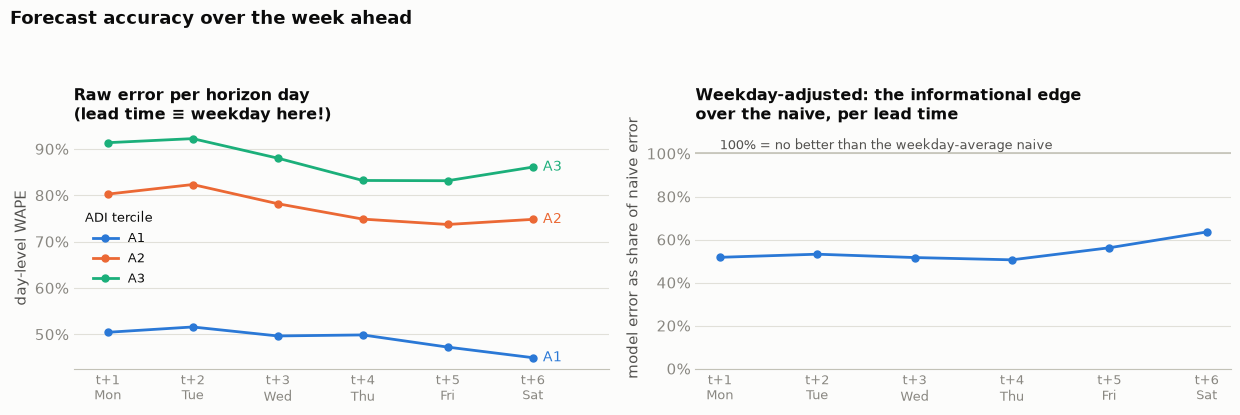

In [6]:
# frozen ADI terciles (classification strictly before the first origin)
CLASSIFICATION_CUTOFF = pd.Timestamp('2026-02-02')
assert CLASSIFICATION_CUTOFF < design.first_origin

series_keys = con.execute('SELECT DISTINCT ARTIKEL_ID, MARKT_ID FROM rows').fetchdf()
con.register('series_keys', series_keys)
frozen_history = con.execute('''
    WITH daily AS (
        SELECT d.ARTIKEL_ID::BIGINT AS ARTIKEL_ID, d.MARKT_ID::BIGINT AS MARKT_ID,
               CAST(d.DATE AS DATE) AS period,
               SUM(CAST(COALESCE(d.ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE)) AS demand
        FROM read_parquet(?) AS d
        JOIN series_keys AS s
          ON d.ARTIKEL_ID = s.ARTIKEL_ID AND d.MARKT_ID = s.MARKT_ID
        WHERE d.is_active AND (d.is_fcm OR d.is_pseudo)
          AND d.WGR_ID IN (890, 900) AND CAST(d.DATE AS DATE) < ?
        GROUP BY 1, 2, 3
    )
    SELECT ARTIKEL_ID, MARKT_ID, COUNT_IF(demand > 0) AS n_pos,
           COUNT(*)::DOUBLE / NULLIF(COUNT_IF(demand > 0), 0) AS ADI
    FROM daily GROUP BY 1, 2
''', [str(design.data_dir / '*.parquet'), CLASSIFICATION_CUTOFF.date()]).fetchdf()
regimes = series_keys.merge(frozen_history, on=['ARTIKEL_ID', 'MARKT_ID'], how='left')
eligible = regimes.n_pos.fillna(0).ge(5)
assert eligible.sum() == 21_140          # same frozen classes as 09_01/09_02
regimes['adi_bin'] = 'unclassified'
regimes.loc[eligible, 'adi_bin'] = pd.qcut(
    regimes.loc[eligible, 'ADI'], 3, labels=['A1', 'A2', 'A3']).astype(str)
con.register('adi', regimes[['ARTIKEL_ID', 'MARKT_ID', 'adi_bin']])

# weekday-matched yardstick with the same information cut-off
con.execute('''
    CREATE OR REPLACE TEMP TABLE naive AS
    SELECT ARTIKEL_ID::BIGINT AS ARTIKEL_ID, MARKT_ID::BIGINT AS MARKT_ID,
           CAST(origin AS DATE) AS origin, CAST(period AS DATE) AS period,
           forecast::DOUBLE AS forecast
    FROM read_csv_auto(?) WHERE is_active
''', [str(result_path('same_weekday_moving_average', design))])

horizon = con.execute('''
    SELECT r.horizon_day,
           ANY_VALUE(strftime(r.period, '%a')) AS weekday,
           SUM(ABS(r.forecast - r.actual)) / SUM(r.actual) AS wape_model,
           SUM(ABS(n.forecast - r.actual)) / SUM(r.actual) AS wape_naive,
           SUM(ABS(r.forecast - r.actual))
               / SUM(ABS(n.forecast - r.actual)) AS error_vs_naive,
           SUM(ABS(r.forecast - r.actual)) FILTER (WHERE adi_bin = 'A1')
               / SUM(r.actual) FILTER (WHERE adi_bin = 'A1') AS wape_A1,
           SUM(ABS(r.forecast - r.actual)) FILTER (WHERE adi_bin = 'A2')
               / SUM(r.actual) FILTER (WHERE adi_bin = 'A2') AS wape_A2,
           SUM(ABS(r.forecast - r.actual)) FILTER (WHERE adi_bin = 'A3')
               / SUM(r.actual) FILTER (WHERE adi_bin = 'A3') AS wape_A3
    FROM rows r
    JOIN naive n USING (ARTIKEL_ID, MARKT_ID, origin, period)
    JOIN adi USING (ARTIKEL_ID, MARKT_ID)
    GROUP BY 1 ORDER BY 1
''').fetchdf()
display(horizon.style.format({c: '{:.1%}' for c in horizon.columns
                              if c.startswith(('wape', 'error'))}).hide(axis='index'))

xt = [f't+{d}\n{w}' for d, w in zip(horizon.horizon_day, horizon.weekday)]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for cls, color in (('A1', BLUE), ('A2', ORANGE), ('A3', AQUA)):
    axes[0].plot(horizon.horizon_day, horizon[f'wape_{cls}'] * 100, color=color,
                 linewidth=2, marker='o', markersize=5, label=f'{cls}')
    axes[0].annotate(cls, (horizon.horizon_day.iloc[-1] + 0.12,
                     horizon[f'wape_{cls}'].iloc[-1] * 100),
                     color=color, fontsize=10, va='center')
axes[0].set_xticks(horizon.horizon_day, xt, fontsize=9)
axes[0].set_ylabel('day-level WAPE')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_title('Raw error per horizon day\n(lead time ≡ weekday here!)',
                  fontsize=11.5)
axes[0].legend(frameon=False, fontsize=9, title='ADI tercile', title_fontsize=9)
axes[0].set_xlim(0.6, 6.9)

axes[1].plot(horizon.horizon_day, horizon.error_vs_naive * 100, color=BLUE,
             linewidth=2, marker='o', markersize=5)
axes[1].axhline(100, color=BASELINE, linewidth=1.2)
axes[1].annotate('100% = no better than the weekday-average naive',
                 (1.0, 102), fontsize=9, color=INK2)
axes[1].set_xticks(horizon.horizon_day, xt, fontsize=9)
axes[1].set_ylabel('model error as share of naive error')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_ylim(0, 112)
axes[1].set_title('Weekday-adjusted: the informational edge\nover the naive, per lead time',
                  fontsize=11.5)
for ax in axes:
    style_ax(ax)
fig.suptitle('Forecast accuracy over the week ahead', x=0.01, ha='left',
             fontweight='bold', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.92))
plt.show()


**Reading — yes, the forecast loses information over the week, but the raw
numbers hide it.**

- **Raw WAPE per horizon day actually *improves*** (58.9% at t+1 down to 54.1% at
  t+6, left panel — with the same ordering in every ADI tercile). That is not the
  model getting better with staleness: t+5/t+6 are Friday/Saturday, the
  highest-volume days, which are intrinsically easier (section 4's volume effect
  again). Lead time and weekday cannot be separated in this design.
- The **weekday-adjusted view** (right panel) shows the real decay: through t+1–t+4
  the model's error is a stable ~51–53% of the weekday-naive's error — it removes
  roughly half of the naive error regardless of lead. At **t+5 it keeps 56%, at t+6
  64%**: about a third of its informational edge over the naive has evaporated by
  Saturday. This is exactly what fading short-term signal looks like — the
  "demand in the last few days" features that dominate the model's importance
  rankings say progressively less about days further out.
- Practical consequence: a **mid-week re-forecast** (e.g. re-issuing Thursday–Saturday
  forecasts on Wednesday evening with three more days of sales data) is the natural
  next lever — it converts the decayed part of the edge back into accuracy without
  touching the model at all. The backtest design (weekly origins) should gain an
  origin scheme with mid-week updates to quantify this.


## 6 · Where the biggest problem sits: sourcing groups

The assortment splits into four sourcing groups: **Pseudo 890** (counter articles cut
and prepared in the store — minced meat, marinated cuts, fresh sausage; category 890),
**FCM 900 / FCM 890** (centrally produced, packaged articles), and a small **Pseudo
900** remainder. Two different questions matter and have different answers:

1. **Where is the most error in absolute kilograms?** (what dominates total cost)
2. **Which group is forecast worst per kilogram sold?** (where the forecast is weakest)


grp,series,kg_sold,volume_share,error_share,wape_day,bias,selling_occurrence
Pseudo 890,"18,608","2,594,744",97.5%,95.9%,56.0%,-0.4%,37.9%
FCM 900,"2,751","59,644",2.2%,3.4%,85.5%,+2.5%,41.8%
FCM 890,320,"4,257",0.2%,0.5%,173.9%,+39.6%,7.7%
Pseudo 900,243,"2,950",0.1%,0.2%,101.2%,+12.0%,31.8%


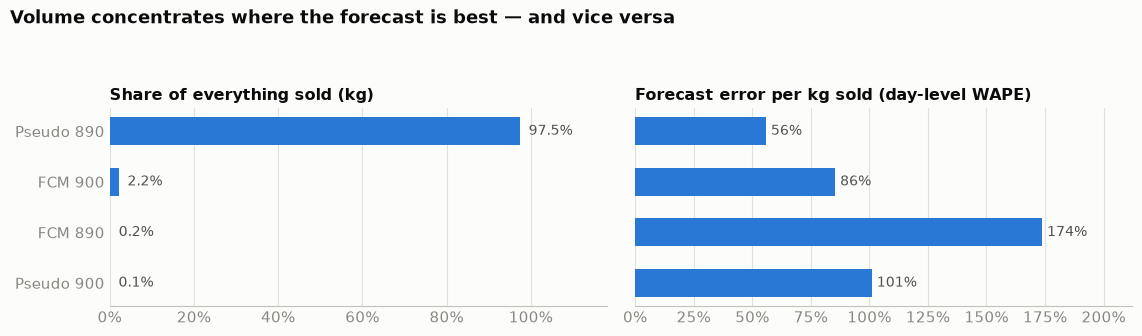

In [7]:
groups = con.execute('''
    SELECT sourcing_group || ' ' || category_id AS grp,
           COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
           SUM(actual) AS kg_sold,
           SUM(actual) / (SELECT SUM(actual) FROM rows) AS volume_share,
           SUM(ABS(forecast - actual))
               / (SELECT SUM(ABS(forecast - actual)) FROM rows) AS error_share,
           SUM(ABS(forecast - actual)) / SUM(actual) AS wape_day,
           SUM(forecast - actual) / SUM(actual) AS bias,
           AVG((actual > 0)::INTEGER) AS selling_occurrence
    FROM rows GROUP BY 1 ORDER BY kg_sold DESC
''').fetchdf()
display(groups.style.format({
    'series': '{:,.0f}', 'kg_sold': '{:,.0f}', 'volume_share': '{:.1%}',
    'error_share': '{:.1%}', 'wape_day': '{:.1%}', 'bias': '{:+.1%}',
    'selling_occurrence': '{:.1%}'}).hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4), sharey=True)
order = groups.sort_values('kg_sold').reset_index(drop=True)
bars0 = axes[0].barh(order.grp, order.volume_share * 100, color=BLUE, height=0.55)
axes[0].set_title('Share of everything sold (kg)', fontsize=11.5)
for bar, v in zip(bars0, order.volume_share):
    axes[0].annotate(f'{v:.1%}', (bar.get_width() + 2,
                     bar.get_y() + bar.get_height() / 2), va='center',
                     fontsize=10, color=INK2)
bars1 = axes[1].barh(order.grp, order.wape_day * 100, color=BLUE, height=0.55)
axes[1].set_title('Forecast error per kg sold (day-level WAPE)', fontsize=11.5)
for bar, v in zip(bars1, order.wape_day):
    axes[1].annotate(f'{v:.0%}', (bar.get_width() + 2,
                     bar.get_y() + bar.get_height() / 2), va='center',
                     fontsize=10, color=INK2)
for ax in axes:
    style_ax(ax, ygrid=False, xgrid=True)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_xlim(0, 118)
axes[1].set_xlim(0, order.wape_day.max() * 100 * 1.22)
fig.suptitle('Volume concentrates where the forecast is best — and vice versa',
             x=0.01, ha='left', fontweight='bold', fontsize=13)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()


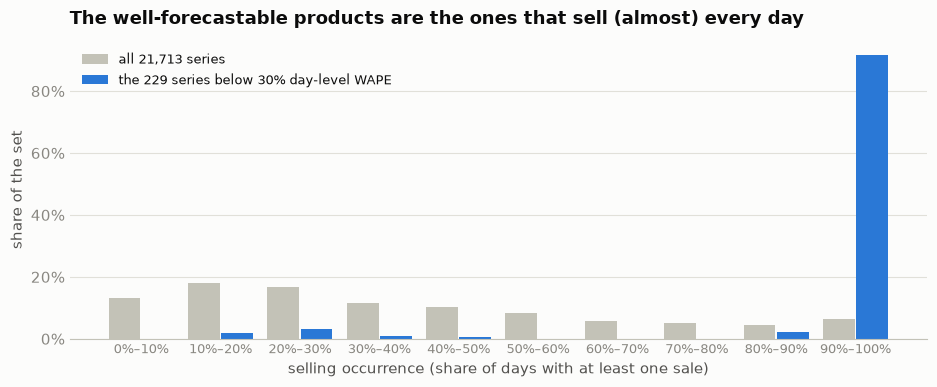

Sourcing-group composition of the <30% set:


,,series,total_kg,mean_occurrence
sourcing_group,category_id,,,
Pseudo,890,229,"349,326",95%


In [8]:
bins = np.arange(0, 1.001, 0.1)
labels = [f'{lo:.0%}–{hi:.0%}' for lo, hi in zip(bins[:-1], bins[1:])]
all_counts, _ = np.histogram(per_series.selling_occurrence.clip(0, 0.999), bins=bins)
good_counts, _ = np.histogram(good.selling_occurrence.clip(0, 0.999), bins=bins)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.5, 4))
ax.bar(x - 0.21, all_counts / all_counts.sum() * 100, width=0.4, color=GRAY,
       label=f'all {len(per_series):,} series')
ax.bar(x + 0.21, good_counts / good_counts.sum() * 100, width=0.4, color=BLUE,
       label=f'the {len(good)} series below 30% day-level WAPE')
style_ax(ax)
ax.set_xticks(x, labels, fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('selling occurrence (share of days with at least one sale)')
ax.set_ylabel('share of the set')
ax.set_title('The well-forecastable products are the ones that sell (almost) every day',
             pad=12)
ax.legend(frameon=False, fontsize=9.5)
plt.tight_layout()
plt.show()

print('Sourcing-group composition of the <30% set:')
display(good.groupby(['sourcing_group', 'category_id'], observed=True)
        .agg(series=('article_name', 'count'), total_kg=('actual_kg', 'sum'),
             mean_occurrence=('selling_occurrence', 'mean'))
        .style.format({'total_kg': '{:,.0f}', 'mean_occurrence': '{:.0%}'}))


**Where the biggest problem sits — two answers for two questions.**

- **In absolute kilograms, Pseudo 890 is the problem** — trivially, because it *is*
  the business: 97.5% of everything sold and 95.9% of all error-kilograms. Yet per kg
  it is the **best**-forecast group (56.0% WAPE, bias −0.4%). Any improvement that
  matters in kg must come from this group, and section 2 showed most of its remaining
  day-level error is irreducible randomness.
- **Per kilogram sold, FCM 890 is by far the worst**: 173.9% WAPE and a **+39.6%
  systematic over-forecast** on articles that sell on only 7.7% of days. This is a
  real model weakness (over-ordering slow movers) — but the group is 0.2% of volume,
  so fixing it is a rounding error in kg. FCM 900 (85.5%, 2.2% of volume) sits in
  between.

**Are the well-forecastable products all Pseudo 890? Yes — all 229 of them** (table
above). The bin plot explains why without any mystery: the <30% set is almost
entirely made of series selling on 90–100% of days, and such daily-staple series
exist only among the store-counter articles. Combined with section 4: forecastability
in this assortment is driven by **selling occurrence and volume, not by sourcing
group** — Pseudo 890 simply contains both the staples (forecastable) and thousands of
slow movers (not individually forecastable, by any method).


## 7 · Aleatoric vs epistemic: naming the remaining uncertainty

Forecast error has two fundamentally different sources, and they demand different
responses:

- **Aleatoric uncertainty** — randomness *in the process itself*. Which customers
  walk into which store on which day, and how much they put in the basket. It cannot
  be reduced by any model, only absorbed (by safety stock) or averaged away (by
  aggregation over days, stores or articles).
- **Epistemic uncertainty** — *our* ignorance: missing input data, imperfect model
  form, finite training data, even the randomness of the training procedure itself.
  This part is reducible — in principle — with more data, better features or better
  models.

The distinction is the economic core of the thesis question "is the remaining error
the model's fault?": money spent on modelling only ever attacks the epistemic share.
This section collects the *measured* evidence for each; the one genuinely missing
measurement gets an explicit plan below.

**Evidence that the dominant share is aleatoric** (all measured above or in `09_01`):

1. **Oracle bounds** (section 2): with perfect knowledge of which days sell, error is
   still 45%; with perfect weekly totals, 44%. At least ~44 of the 57 error-points
   are therefore beyond *any* information a forecaster could legally have.
2. **Counting-statistics scaling** (section 4): among daily sellers WAPE falls with
   volume along the 1/√volume curve that pure customer-arrival randomness predicts,
   and the biggest staples sit near that floor — their error is *fully explained* by
   arrival noise.
3. **Aggregation behaves exactly as random noise must**: the identical forecasts
   score 56.9% at store-day, 36.4% at store-week, 23.4% at article-day and 19.9% at
   article-week — independent random errors cancel under summation; systematic
   (epistemic) error would not.

**Evidence on the epistemic share — it exists, is measurable, and is small at the
margin.** All numbers below are measured on the final dataset and feature set
(`transactions_fixed`, feature contract `2026-08-16.3` incl. temperature and
action-campaign features), except where a bound is explicitly labelled otherwise:


**Training randomness** is measured per row in `10_03_epistemic_ensemble.ipynb`
(a deep ensemble of the shipped mainline on the final configuration): the model's
disagreement with itself is negligible against the aleatoric spread — see there
for the numbers and plots.

The other measured epistemic components:

| component | type of ignorance | measured size (day-level) |
|---|---|---|
| training randomness | epistemic — procedure | negligible — measured in `10_03` |
| occurrence-stage headroom vs a *perfect* classifier (section 2) | epistemic — model | ≤ 12 pp bound; realistic fraction far smaller |
| lead-time information decay (section 5) | epistemic — stale inputs | edge over naive shrinks from ~49% to ~36% by t+6; recoverable by mid-week re-forecasting |
| store-level spontaneous markdowns invisible to the model | epistemic — missing data | order-of-magnitude bound only: ~4 pp if perfectly known (`09_01` audit, measured on the pre-fix data version); ~0.5–1.5 pp realistically |
| the last feature batch (`08_04`, identical data and design) | epistemic — features | −0.53 pp (57.44% → 56.92%) actually removed |

Every epistemic component we can measure is of the order of *tenths to a few*
percentage points — against an aleatoric floor of ~44–45 points. That asymmetry is
the quantitative answer to "model or data".


### What is *not* yet measured — and the plan to measure it

The evidence above brackets the two uncertainties with bounds and proxies, but the
thesis does not yet have a **per-row predictive distribution**, so the split
aleatoric/epistemic is not quantified *per forecast* (e.g. "this Saturday order of
14 kg has a 80%-interval of 9–21 kg, of which almost all is aleatoric"). Plan, in
order of value per effort:

1. **Quantile refit (aleatoric per row) — DONE, see `10_02_quantile_uncertainty.ipynb`.** Refit the two-stage quantity stage with
   pinball (quantile) loss at P10/P50/P90 under the unchanged backtest design —
   the registry pattern in `src/models/lightgbm/` supports adding a variant with its
   own config. Deliverables: interval **coverage** (do ~80% of actuals fall inside
   P10–P90, per ADI tercile and per sourcing group?) and **sharpness** (interval
   width vs volume — prediction: width ≈ the 1/√volume law of section 4). Correct
   coverage with widths matching counting noise would *confirm* the aleatoric story
   at row level; systematic under-coverage in a segment would localise hidden
   epistemic error.
2. **Deep ensemble on the current mainline (epistemic per row) — DONE, see `10_03_epistemic_ensemble.ipynb`.** Re-run the 5-seed
   ensemble on the *current* feature set (the existing runs predate `08_04`) and
   report the per-row seed variance as the epistemic term next to the quantile
   width as the aleatoric term — the standard variance decomposition
   (epistemic = disagreement between members, aleatoric = width within a member).
3. **Conformal calibration — DONE, see `10_04_conformal_calibration.ipynb`.** Wrap the P10/P90 interval in split-conformal
   adjustment using origins 1–10 as calibration and 11–20 as test, so the coverage
   claim is distribution-free rather than model-trusting.

Item 1 is a single registered model variant plus one evaluation notebook; items 2–3
are evaluation-only. None of them changes the point forecast — they change what we
can *claim* about it.


## 8 · Summary of answers

**1 · How good is the final forecast?** 56.9% WAPE at article × store × day with
−0.3% bias, i.e. without systematic over- or under-ordering. Under aggregation the
same forecasts reach 36.4% (store-week), 23.4% (article-day) and 19.9%
(article-week).

**2 · Model or data? Mostly data — and now stated precisely.** The remaining
day–store error is dominated by **aleatoric uncertainty**: oracles fed the actual
future still miss by 44–45%, the staples' error tracks the 1/√volume counting-noise
curve, and errors cancel under aggregation exactly as independent randomness must.
Every **epistemic** component we can measure is small at the margin:
training randomness is negligible (measured in `10_03`), occurrence headroom is
bounded at 12 pp by an unattainable perfect classifier, invisible store markdowns
are worth ~4 pp at most (pre-fix-data bound), and the last feature batch bought
−0.53 pp on identical data. The per-row decomposition via quantile loss, deep
ensemble and conformal calibration is delivered in `10_02`–`10_04` (section 7
plan, all items done).

**3 · Does accuracy decay over the week?** Raw numbers say no (Saturdays are easy),
but that is a design artefact — lead time equals weekday in this backtest. Measured
against a weekday-matched naive, the model keeps a constant edge through t+4 and
then loses about a third of it by t+6. A mid-week re-forecast would recover most of
that decay without any model change.

**4 · Well-forecast products, and why.** Below 20% day-level WAPE: exactly one
series (mixed minced meat, store 19). Below 30%: 229 series carrying 13.1% of
volume — twelve fresh-counter staples selling on ~95% of days, **all Pseudo 890**.
The driver is **not** "good seasonality" (their weekday rhythm is *weaker* than
their peers') but **scale**: at ~13 kg/day, customer-arrival noise alone sets a
~25–30% floor, and the staples sit near it. At week level, 42% of volume is already
below 30%.

**5 · Sourcing groups.** The error volume sits in Pseudo 890 because ~all volume
does (97.5%) — while its per-kg forecast is the best (56.0%, unbiased). The per-kg
problem group is FCM 890 (173.9% WAPE, +39.6% over-forecast) — a real weakness, but
0.2% of volume. Forecastability is governed by selling occurrence and volume, not by
sourcing group.
